In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

In [ ]:
import pandas as pd

confirmed = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv")

deaths = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_US.csv")

In [ ]:
print(confirmed.head())

        UID iso2 iso3  code3    FIPS   Admin2 Province_State Country_Region  \
0  84001001   US  USA    840  1001.0  Autauga        Alabama             US   
1  84001003   US  USA    840  1003.0  Baldwin        Alabama             US   
2  84001005   US  USA    840  1005.0  Barbour        Alabama             US   
3  84001007   US  USA    840  1007.0     Bibb        Alabama             US   
4  84001009   US  USA    840  1009.0   Blount        Alabama             US   

         Lat      Long_  ... 2/28/23  3/1/23  3/2/23  3/3/23  3/4/23  3/5/23  \
0  32.539527 -86.644082  ...   19732   19759   19759   19759   19759   19759   
1  30.727750 -87.722071  ...   69641   69767   69767   69767   69767   69767   
2  31.868263 -85.387129  ...    7451    7474    7474    7474    7474    7474   
3  32.996421 -87.125115  ...    8067    8087    8087    8087    8087    8087   
4  33.982109 -86.567906  ...   18616   18673   18673   18673   18673   18673   

   3/6/23  3/7/23  3/8/23  3/9/23  
0   1975

In [ ]:
state = "California"

df = confirmed[confirmed["Province_State"] == state]

df = df.drop(columns=[
    "UID","iso2","iso3","code3","FIPS","Admin2",
    "Province_State","Country_Region","Lat","Long_","Combined_Key"
])

ts = df.sum()
ts.index = pd.to_datetime(ts.index)
ts = ts.sort_index()

/tmp/ipykernel_4023/164578704.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts.index = pd.to_datetime(ts.index)


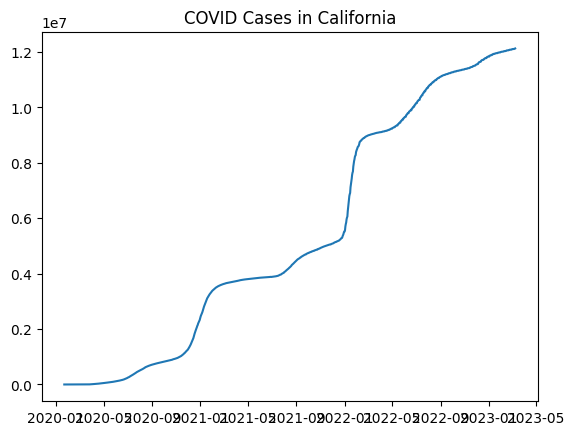

In [ ]:
plt.figure()
plt.plot(ts)
plt.title("COVID Cases in California")
plt.show()

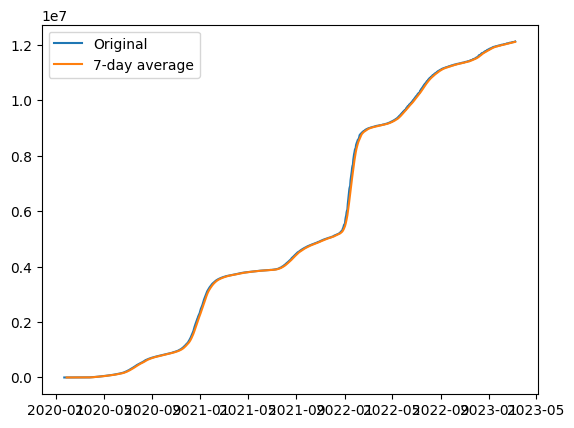

In [ ]:
roll_mean = ts.rolling(7).mean()

plt.figure()
plt.plot(ts, label="Original")
plt.plot(roll_mean, label="7-day average")
plt.legend()
plt.show()

In [ ]:
result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.0016697016228943522
p-value: 0.9583937848904162


In [ ]:
train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test = ts[train_size:]

In [ ]:
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


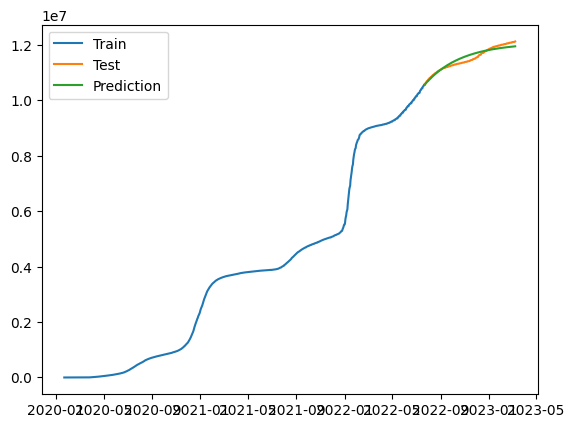

In [ ]:
plt.figure()
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Prediction")
plt.legend()
plt.show()

In [ ]:
mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", mape)

MAPE: 0.864293690783518
